# 04 — influences: an artist's background as weights over the corpus

**Summary.** Seven subjects — three positions and four lineage elements — each resolved to **48
corpus works** by embedding phrases lifted *verbatim* out of their own files and retrieving the
nearest images. This is **retrieval, not reading**: nothing has looked at any of these works, and
each is present only because its photograph is near a sentence.

What is real, against baselines:

* **Dimensionality moves the way the input does.** `many-hands` comes back **58.3% 2D** against a
  corpus rate of 14.7% (4.0x); `kuba-shoowa-surface`, whose lineage is textiles and objects, comes
  back **8.3%**, *below* corpus rate. A measure that only ever goes up is a measure of the method;
  this one goes both ways.
* **The sets are distinguished from each other.** Max Jaccard over sha256 across all 21 pairs is
  **0.0435**, and 4 of the 21 pairs share nothing at all.
* **Classification entropy is narrower than chance for 5 of 7** — the sets are not random draws.

**NOTHING MEASURED**, said plainly:

* **Same-museum share.** All seven sets sit inside the chance band around 39.0%. The queries do not
  steer the museum.
* **Medium entropy.** All seven sit inside their chance bands.
* **Intra-set coherence.** Mean intra-set cosine lands at the corpus's own median (0.64), i.e. a
  resolved set is not internally more alike than a random pair of corpus works.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import kusama as k

ids = k.influence_ids()
R = {i: k.load_influences(i) for i in ids}
b = k.band()
print(f"{len(ids)} resolved sets:", ", ".join(ids))

7 resolved sets: chromolith-broadside, interference, kuba-shoowa-surface, ma-interval, many-hands, rodchenko-red-black, withheld


## Every set, every number, with its baseline in the next column

In [2]:
rows = []
for i, r in R.items():
    s = r["stats"]
    cls = next(e for e in s["entropy"] if e["field"] == "classification")
    med = next(e for e in s["entropy"] if e["field"] == "medium")
    rows.append(dict(
        set=i, n=s["n"],
        same_museum=s["sameMuseum"], mus_chance=s["sameMuseumChance"],
        intra=s["intraMean"], band_median=b["median"],
        cls_H=cls["measured"], cls_lo=cls["chanceLo"], cls_hi=cls["chanceHi"],
        med_H=med["measured"], med_lo=med["chanceLo"], med_hi=med["chanceHi"],
        twoD=s["dimensionality"]["twoDShare"], corpus2D=s["dimensionality"]["corpusTwoDShare"],
        axis0=r["axes"][0]["explained"],
    ))
df = pd.DataFrame(rows).set_index("set")
pd.set_option("display.width", 200)
print(df.round(4).to_string())

                       n  same_museum  mus_chance   intra  band_median   cls_H  cls_lo  cls_hi   med_H  med_lo  med_hi    twoD  corpus2D   axis0
set                                                                                                                                             
chromolith-broadside  48       0.3910      0.3897  0.6202       0.6428  5.0098  5.2933   5.585  5.3192  5.1109  5.5433  0.4792     0.147  0.2042
interference          48       0.4184      0.3897  0.6918       0.6428  5.3766  5.2933   5.585  5.5016  5.1109  5.5433  0.2500     0.147  0.1195
kuba-shoowa-surface   48       0.4184      0.3897  0.6601       0.6428  5.3192  5.2933   5.585  5.3452  5.1109  5.5433  0.0833     0.147  0.1789
ma-interval           48       0.4016      0.3897  0.6181       0.6428  5.1339  5.2933   5.585  5.2202  5.1109  5.5433  0.5000     0.147  0.1331
many-hands            48       0.3652      0.3897  0.6572       0.6428  4.6012  5.2933   5.585  5.1764  5.1109  5.5433  0.5833    

## Read that table honestly, column by column

A number is only a finding if it is outside the band it would sit in by chance. Three of the six
columns are not.

In [3]:
def verdict(row):
    out = []
    inside_cls = row.cls_lo <= row.cls_H <= row.cls_hi
    inside_med = row.med_lo <= row.med_H <= row.med_hi
    out.append(f"museum {row.same_museum:.3f} vs {row.mus_chance:.3f} — "
               f"{'NOTHING MEASURED (inside chance)' if abs(row.same_museum-row.mus_chance) < 0.05 else 'moved'}")
    out.append(f"classification H {row.cls_H:.3f} in [{row.cls_lo:.3f},{row.cls_hi:.3f}] — "
               f"{'inside chance' if inside_cls else 'NARROWER than chance'}")
    out.append(f"medium H {row.med_H:.3f} in [{row.med_lo:.3f},{row.med_hi:.3f}] — "
               f"{'NOTHING MEASURED (inside chance)' if inside_med else 'NARROWER than chance'}")
    out.append(f"2D {row.twoD:.3f} vs corpus {row.corpus2D:.3f} — {row.twoD/row.corpus2D:.2f}x")
    return out

for name, row in df.iterrows():
    print(f"\n{name}")
    for line in verdict(row):
        print("   " + line)


chromolith-broadside
   museum 0.391 vs 0.390 — NOTHING MEASURED (inside chance)
   classification H 5.010 in [5.293,5.585] — NARROWER than chance
   medium H 5.319 in [5.111,5.543] — NOTHING MEASURED (inside chance)
   2D 0.479 vs corpus 0.147 — 3.26x

interference
   museum 0.418 vs 0.390 — NOTHING MEASURED (inside chance)
   classification H 5.377 in [5.293,5.585] — inside chance
   medium H 5.502 in [5.111,5.543] — NOTHING MEASURED (inside chance)
   2D 0.250 vs corpus 0.147 — 1.70x

kuba-shoowa-surface
   museum 0.418 vs 0.390 — NOTHING MEASURED (inside chance)
   classification H 5.319 in [5.293,5.585] — inside chance
   medium H 5.345 in [5.111,5.543] — NOTHING MEASURED (inside chance)
   2D 0.083 vs corpus 0.147 — 0.57x

ma-interval
   museum 0.402 vs 0.390 — NOTHING MEASURED (inside chance)
   classification H 5.134 in [5.293,5.585] — NARROWER than chance
   medium H 5.220 in [5.111,5.543] — NOTHING MEASURED (inside chance)
   2D 0.500 vs corpus 0.147 — 3.40x

many-hands
   m

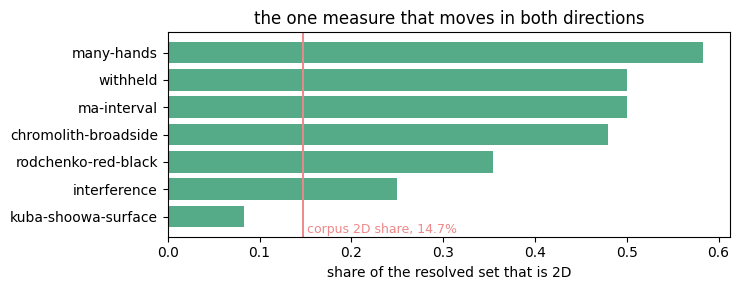

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 3.0))
o = df.sort_values("twoD")
ax.barh(o.index, o.twoD, color="#5a8")
ax.axvline(o.corpus2D.iloc[0], color="#e88", lw=1.4)
ax.text(o.corpus2D.iloc[0], -0.6, " corpus 2D share, 14.7%", color="#e88", fontsize=9)
ax.set_xlabel("share of the resolved set that is 2D")
ax.set_title("the one measure that moves in both directions")
fig.tight_layout(); plt.show()

## Are the sets distinguished from each other?

If two positions with different lineages resolved to the same works, the queries would not be
carrying the position and this whole construction would be decoration.

In [5]:
J = pd.DataFrame(index=ids, columns=ids, dtype=float)
for a in ids:
    for c in ids:
        A, B = {w["sha256"] for w in R[a]["works"]}, {w["sha256"] for w in R[c]["works"]}
        J.loc[a, c] = len(A & B) / len(A | B)
off = J.where(~np.eye(len(ids), dtype=bool))
print(f"Jaccard over sha256 — max off-diagonal {off.max().max():.4f}, "
      f"{int((off == 0).sum().sum()//2)} of {len(ids)*(len(ids)-1)//2} pairs share NOTHING")
print(J.round(3).to_string())

Jaccard over sha256 — max off-diagonal 0.0435, 4 of 21 pairs share NOTHING
                      chromolith-broadside  interference  kuba-shoowa-surface  ma-interval  many-hands  rodchenko-red-black  withheld
chromolith-broadside                 1.000         0.011                0.000        0.032       0.021                0.011     0.011
interference                         0.011         1.000                0.021        0.043       0.011                0.032     0.043
kuba-shoowa-surface                  0.000         0.021                1.000        0.021       0.000                0.000     0.021
ma-interval                          0.032         0.043                0.021        1.000       0.021                0.000     0.043
many-hands                           0.021         0.011                0.000        0.021       1.000                0.011     0.011
rodchenko-red-black                  0.011         0.032                0.000        0.000       0.011                1.0

## The principal axes

Each set gets three axes by power iteration with deflation over its own 48 vectors. The labels are
generated from the works at each end, and `explained` is the share of the set's variance the axis
carries. **These must be non-increasing** — that is a property of principal axes, not of the data,
which makes it a free correctness check. It caught a real bug: a power iteration seeded with a
non-unit vector broke after one step and returned near-noise that printed as 10.2% / 22.0% / 4.2%.

In [6]:
for i, r in R.items():
    ex = [a["explained"] for a in r["axes"]]
    ok = all(ex[j] >= ex[j+1] for j in range(len(ex)-1))
    print(f"{i:<24} " + "  ".join(f"{e:.4f}" for e in ex) + ("   ordered" if ok else "   *** NOT ORDERED ***"))
    for a in r["axes"][:1]:
        print(f"{'':<24} axis 0: {a['label']}")

chromolith-broadside     0.2042  0.0763  0.0623   ordered
                         axis 0: woodcut -> textile; aic -> met
interference             0.1195  0.0981  0.0635   ordered
                         axis 0: lace -> textile; met -> aic
kuba-shoowa-surface      0.1789  0.1360  0.0763   ordered
                         axis 0: fragment -> sculpture
ma-interval              0.1331  0.1056  0.0713   ordered
                         axis 0: aerophone-blow hole-vessel flute -> woodblock print; met -> aic
many-hands               0.2209  0.1401  0.0591   ordered
                         axis 0: bound volume -> amulet, double horns; cma -> met
rodchenko-red-black      0.1237  0.1082  0.0709   ordered
                         axis 0: relief etching -> furniture and woodwork
withheld                 0.2747  0.0739  0.0614   ordered
                         axis 0: calligraphy -> furniture; aic -> met


## What the sets look like

Weight order, so the first cells are the works the queries pulled hardest.


chromolith-broadside — 48 works, spread 0.793, axis 0 = woodcut -> textile; aic -> met


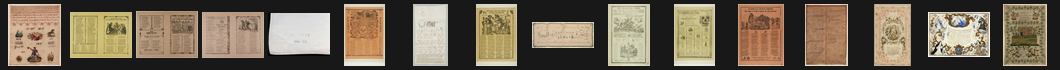


interference — 48 works, spread 0.836, axis 0 = lace -> textile; met -> aic


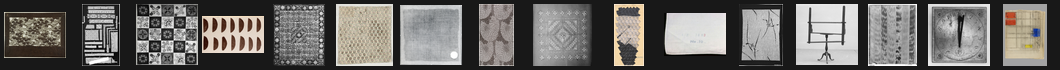


kuba-shoowa-surface — 48 works, spread 0.817, axis 0 = fragment -> sculpture


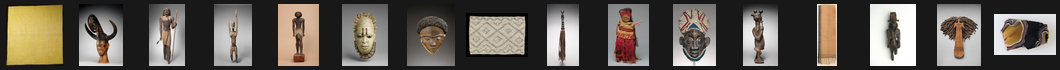


ma-interval — 48 works, spread 0.791, axis 0 = aerophone-blow hole-vessel flute -> woodblock print; met -> aic


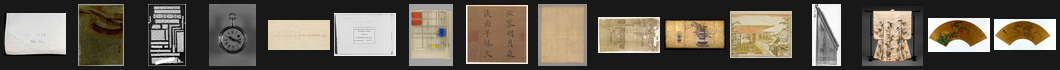


many-hands — 48 works, spread 0.815, axis 0 = bound volume -> amulet, double horns; cma -> met


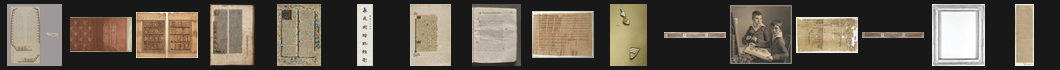


rodchenko-red-black — 48 works, spread 0.795, axis 0 = relief etching -> furniture and woodwork


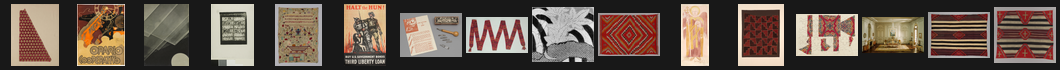


withheld — 48 works, spread 0.806, axis 0 = calligraphy -> furniture; aic -> met


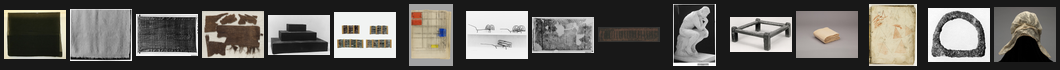

In [7]:
for i in ids:
    r = R[i]
    print(f"\n{i} — {len(r['works'])} works, spread {r['spread']:.3f}, "
          f"axis 0 = {r['axes'][0]['label']}")
    display(k.thumb_grid([w["sha256"] for w in r["works"][:16]], cols=16, size=62))

## What this does NOT establish

**No corpus image has reached an artist through any of this.** These sets are a construction over
the corpus, resolved offline, with no model call. Whether an influence set changes what gets made is
a question about a run, and no run has used one. Stage 5 is where that would happen.

## Scratch

In [8]:
# yours